# 数据增强代码实现

In [ ]:
def getCtAngmentedCandidate(
    augmentation_dict,
    series_uid, center_xyz, width_irc, use_cache=True):
    if use_cache:
        ct_chunk, center_irc = getCtRawCandidate(series_uid, center_xyz, width_irc)
    else:
        ct = getCt(series_uid)
        ct_chunk, center_irc = ct.getRawCandidate(center_xyz, width_irc)
    ct_t = torch.tensor(ct_chunk).unsqueeze(0).unsqueeze(0).to(torch.float32)
    
    transform_t = torch.eye(4)
    
    for i in range(3):
        #镜像方法
        if 'flip' in augmentation_dict:
            if random.random() > 0.5:
                transform_t[i,i] *= -1
        #offset 随机偏移
        if 'offset' in augmentation_dict:
            offset_float = augmentation_dict['offset']
            random_float = (random.random() * 2 - 1)
            transform_t[i,3] = offset_float * random_float
            
        #scale 随机缩放
        if 'scale' in augmentation_dict:
            scale_float = augmentation_dict['scale']
            random_float = (random.random() * 2 - 1)
            transform_t[i,i] *= 1.0 + scale_float * random_float
            
    #rotate 随机旋转
    if 'rotate' in augmentation_dict:
        angle_rad = random.random() * math.pi * 2
        s = math.sin(angle_rad)
        c = math.cos(angle_rad)
        
        rotation_t = torch.tensor([
            [c, -s, 0, 0],
            [s, c, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])
        
        transform_t @= rotation_t  # @=操作符是将右侧的矩阵与左侧的矩阵进行矩阵乘法，并将结果赋值给左侧变量
        
    affine_t = F.affine_grid(
        transform_t[:3].unsqueeze(0).to(torch.float32),
        ct_t.size(),
        align_corners=False,
        )
    augmented_chunk = F.grid_sample(
            ct_t,
        affine_t,
        padding_mode = 'border',
        align_corners = False,
    ).to('cpu')
    
    #noise 加噪声
    if 'noise' in augmenttation_dict:
        noise_t = torch.randn_like(augmented_chunk)
        noise_t *= augmentation_doct['noise']
        
        augmented_chunk += noise_t
        
    return augmented_chunk[0], center_irc

In [4]:
%matplotlib inline
import torch
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # 添加在导入任何库之前
import copy
import numpy as np
import matplotlib.pyplot as plt


In [5]:


from code2.dsets import getCandidateInfoList, getCt, LunaDataset
from util.util import xyz2irc

In [6]:
candidateInfo_list = getCandidateInfoList(requireOnDisk_bool=False)
candidateInfo_list[0]

CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))

In [7]:
from code2.vis import findPositiveSamples, showCandidate
positiveSample_list = findPositiveSamples()

2025-05-03 18:00:29,589 INFO     pid:7692 code2.dsets:266:__init__ <code2.dsets.LunaDataset object at 0x0000027713A4DA60>: 164991 training samples, 164573 neg, 418 pos, unbalanced ratio


0 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))
1 CandidateInfoTuple(isNodule_bool=True, diameter_mm=27.07544345, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.481278873893653517789960724156', center_xyz=(-102.571208, -5.186558766, -205.1033412))
2 CandidateInfoTuple(isNodule_bool=True, diameter_mm=25.23320204, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.511347030803753100045216493273', center_xyz=(63.4740118048, 73.9174523314, -213.736128767))
3 CandidateInfoTuple(isNodule_bool=True, diameter_mm=23.48374545, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.148447286464082095534651426689', center_xyz=(-90.1922382588, 32.9077042197, -127.738768532))
4 CandidateInfoTuple(isNodule_bool=True, diameter_mm=23.48374545, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.148447286464082095534651426689', center_xyz=(-93.9441715503, 28.8165564567, -130.2

In [8]:
augmentation_dict = {}
augmentation_list = [
    ('None', {}),
    ('flip', {'flip': True}),
    ('offset', {'offset': 0.1}),
    ('scale', {'scale': 0.2}),
    ('rotate', {'rotate': True}),
    ('noise', {'noise': 25.0}),    
]
ds_list = [
    LunaDataset(sortby_str='label_and_size', augmentation_dict=augmentation_dict) 
    for title_str, augmentation_dict in augmentation_list
]

all_dict = {}
for title_str, augmentation_dict in augmentation_list:
    all_dict.update(augmentation_dict)
all_ds = LunaDataset(sortby_str='label_and_size', augmentation_dict=all_dict)

augmentation_list.extend([('All', augmentation_dict)] * 3)
ds_list.extend([all_ds] * 3)

2025-05-03 18:00:31,889 INFO     pid:7692 code2.dsets:266:__init__ <code2.dsets.LunaDataset object at 0x0000027707E34B00>: 164991 training samples, 164573 neg, 418 pos, unbalanced ratio
2025-05-03 18:00:31,920 INFO     pid:7692 code2.dsets:266:__init__ <code2.dsets.LunaDataset object at 0x0000027707E351C0>: 164991 training samples, 164573 neg, 418 pos, unbalanced ratio
2025-05-03 18:00:31,943 INFO     pid:7692 code2.dsets:266:__init__ <code2.dsets.LunaDataset object at 0x0000027712468200>: 164991 training samples, 164573 neg, 418 pos, unbalanced ratio
2025-05-03 18:00:31,970 INFO     pid:7692 code2.dsets:266:__init__ <code2.dsets.LunaDataset object at 0x0000027712494CB0>: 164991 training samples, 164573 neg, 418 pos, unbalanced ratio
2025-05-03 18:00:31,994 INFO     pid:7692 code2.dsets:266:__init__ <code2.dsets.LunaDataset object at 0x00000277124F0E00>: 164991 training samples, 164573 neg, 418 pos, unbalanced ratio
2025-05-03 18:00:32,020 INFO     pid:7692 code2.dsets:266:__init__ <co

torch.Size([1, 32, 48, 48]) (tensor([0, 1]), '1.3.6.1.4.1.14519.5.2.1.6279.6001.197063290812663596858124411210', tensor([114, 280, 375]))


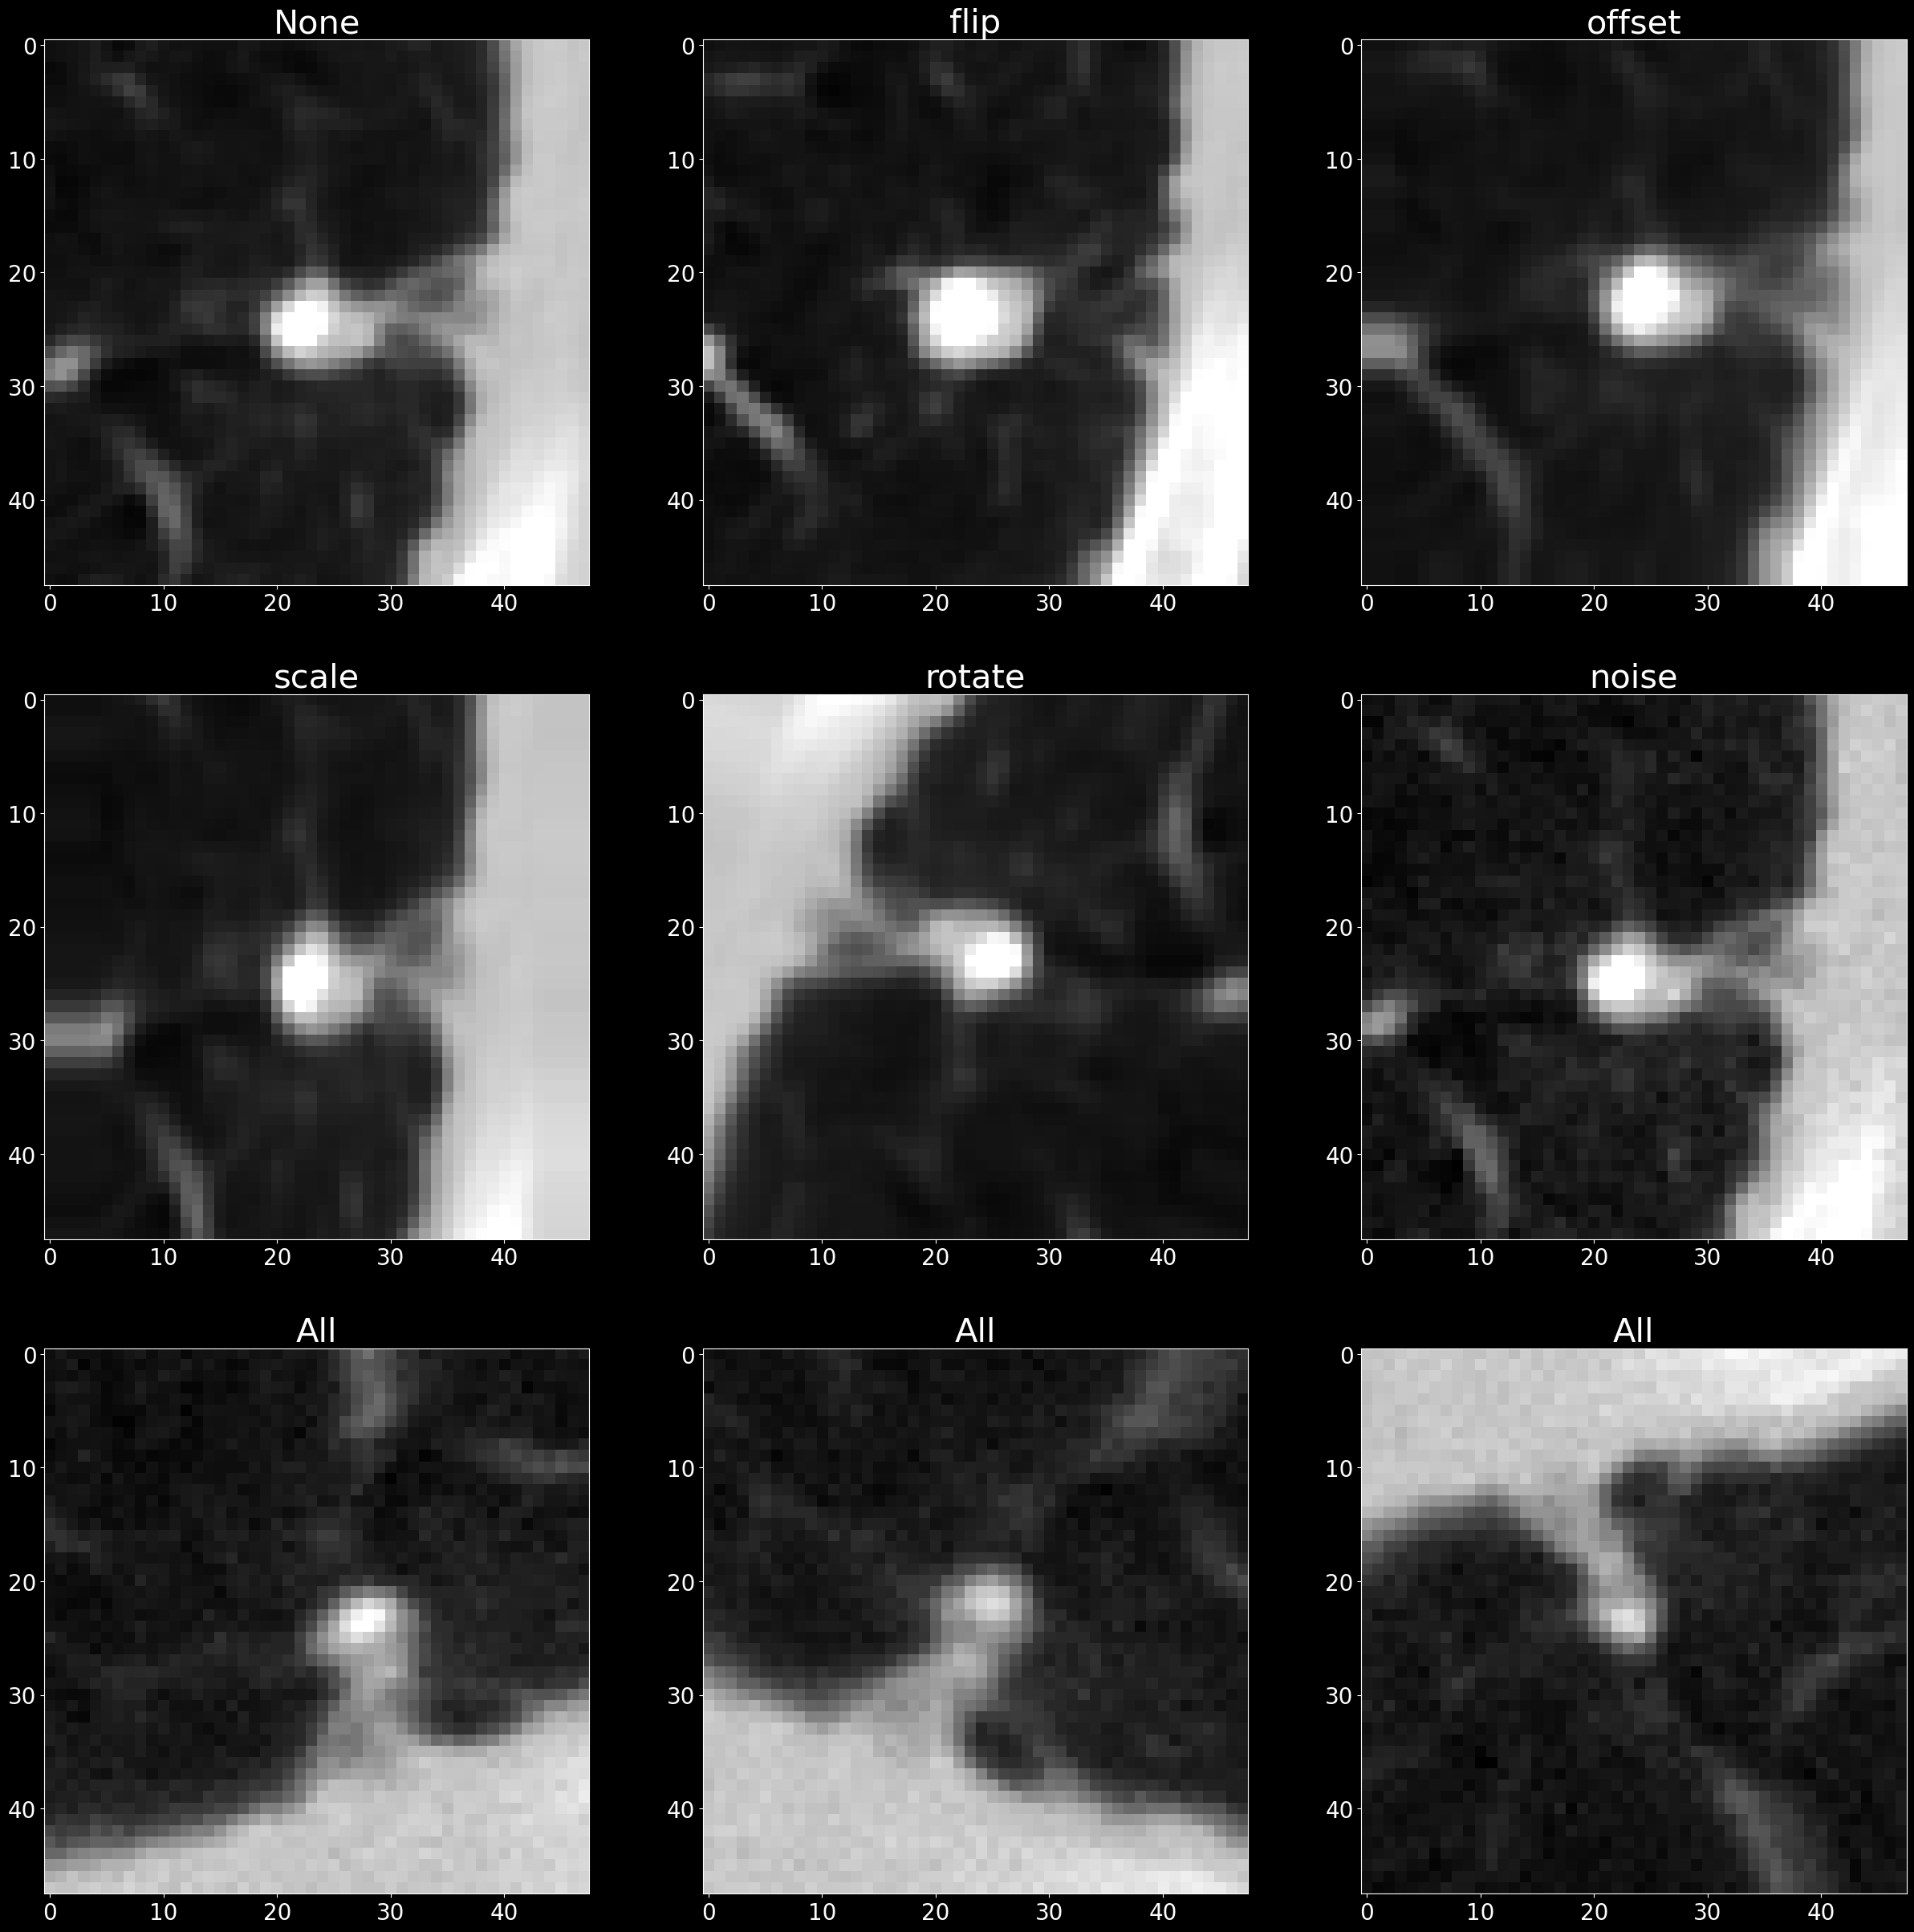

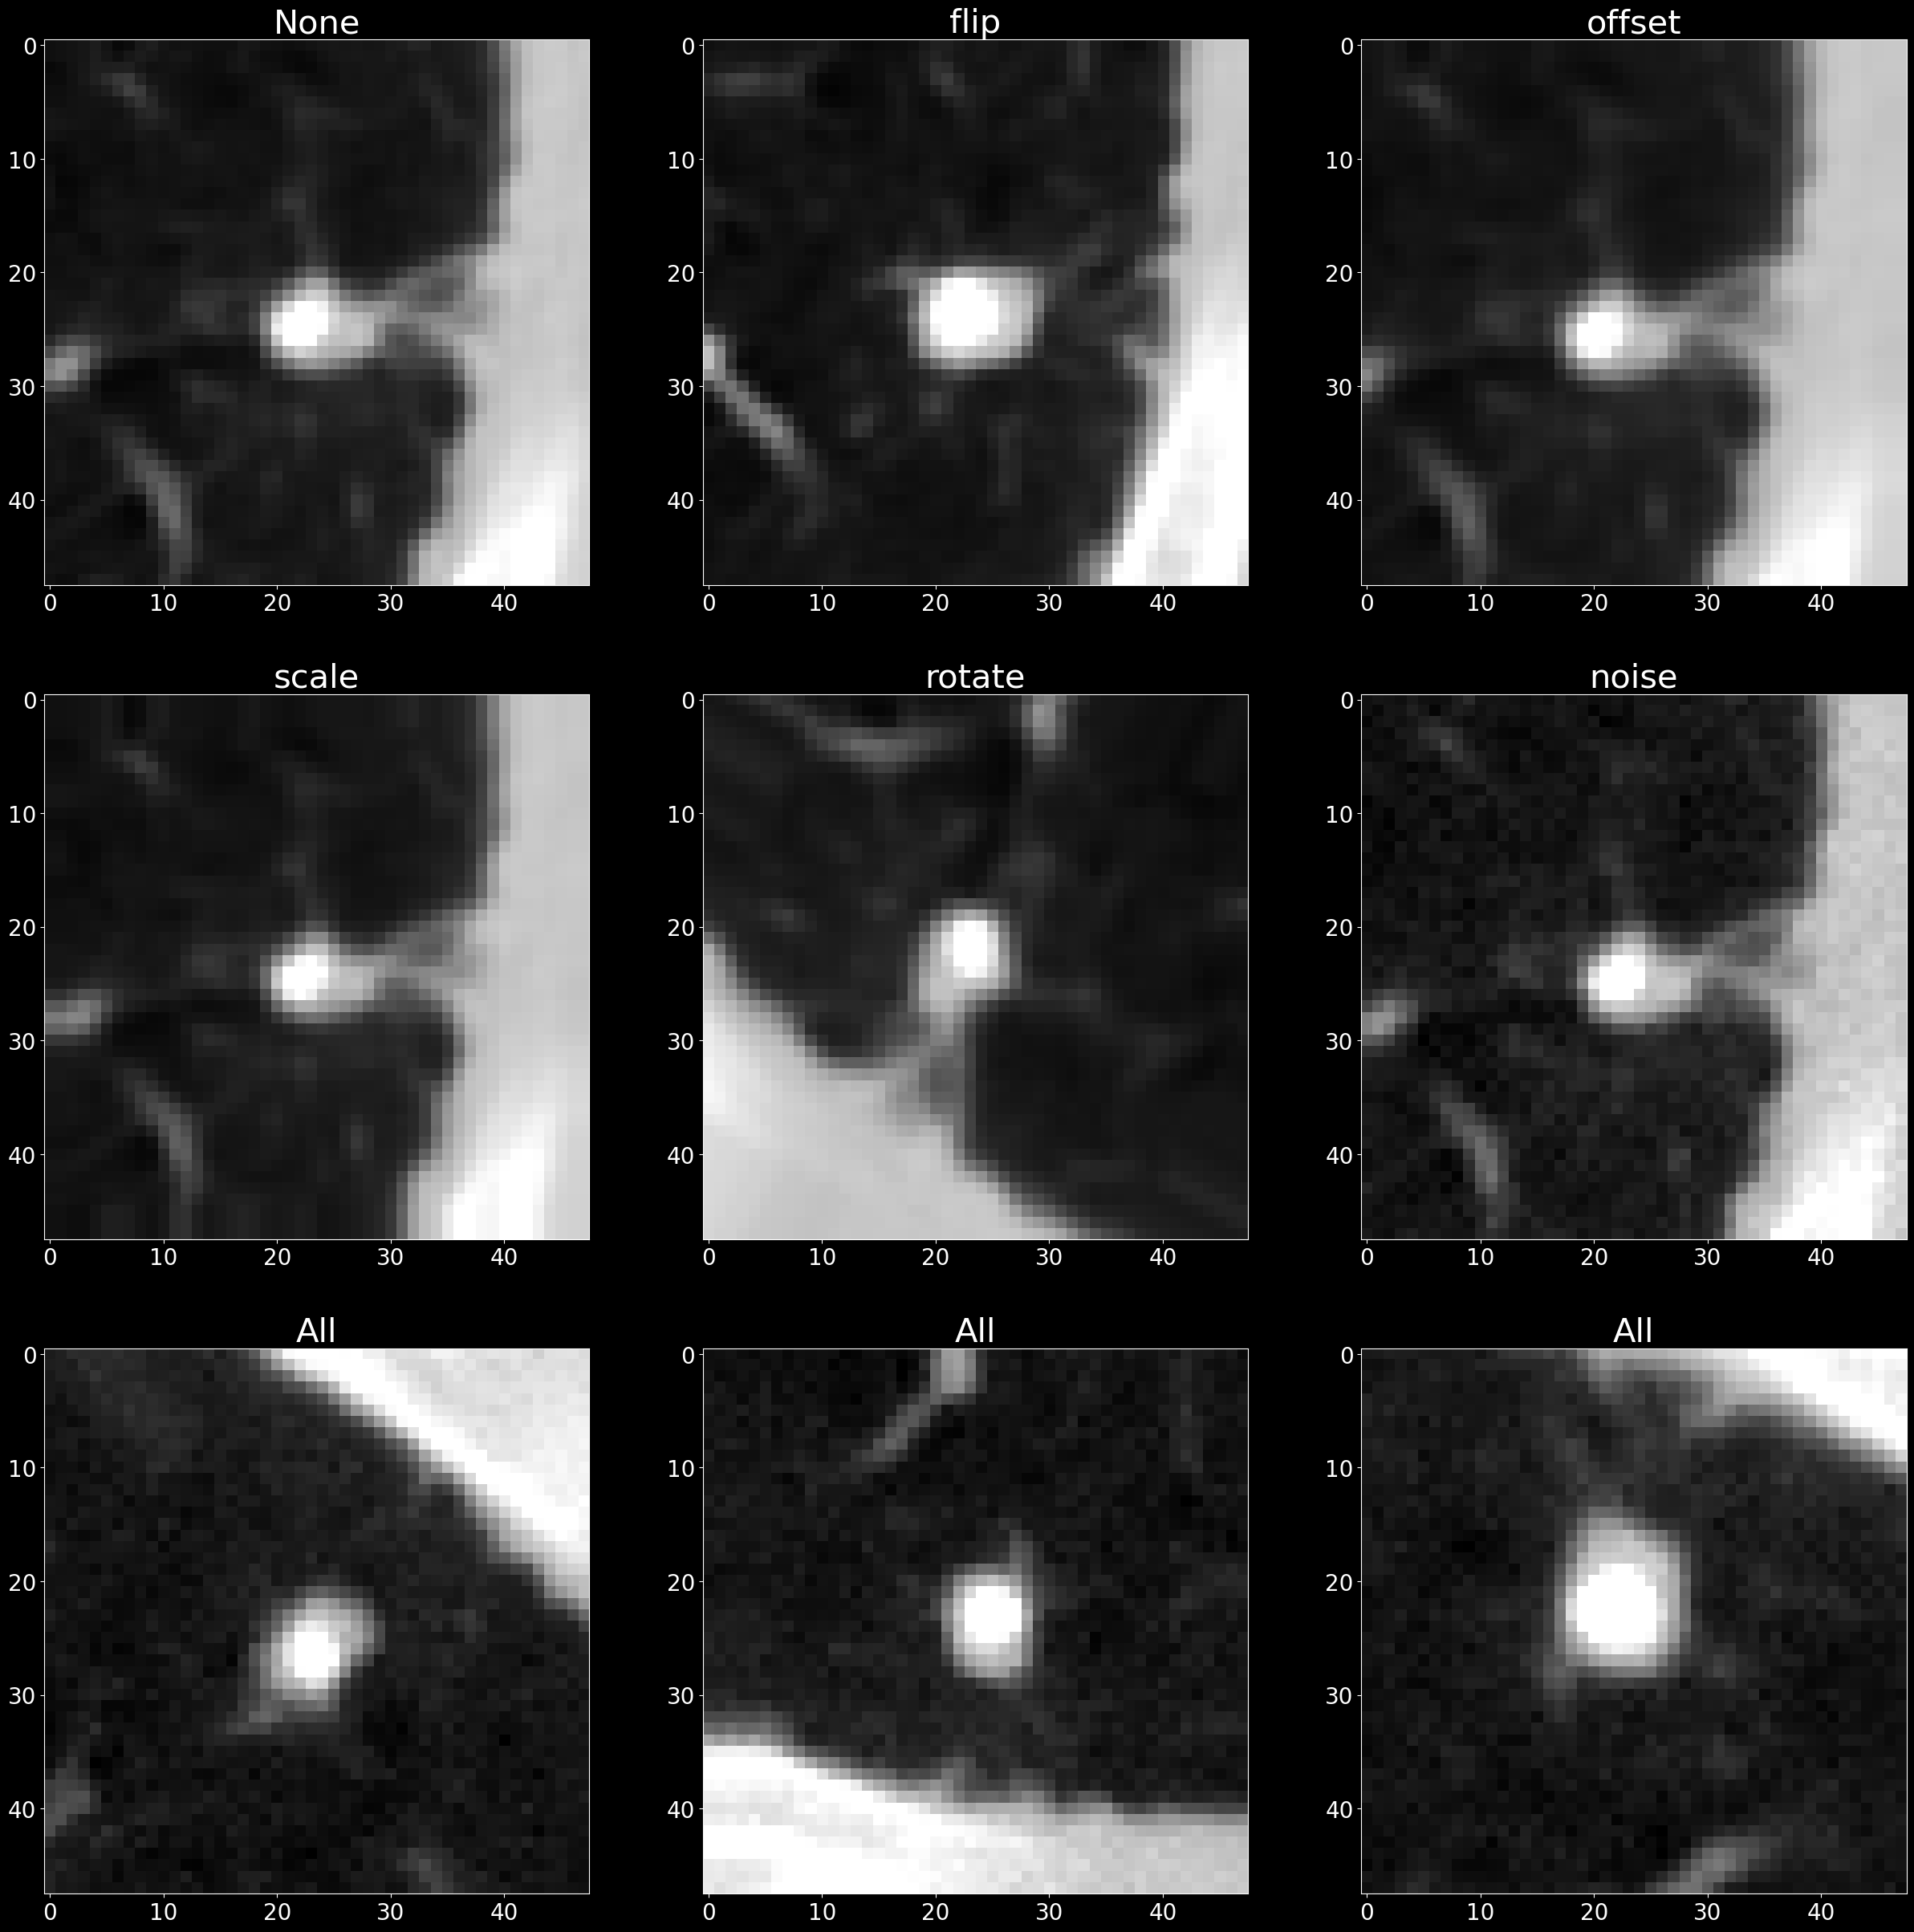

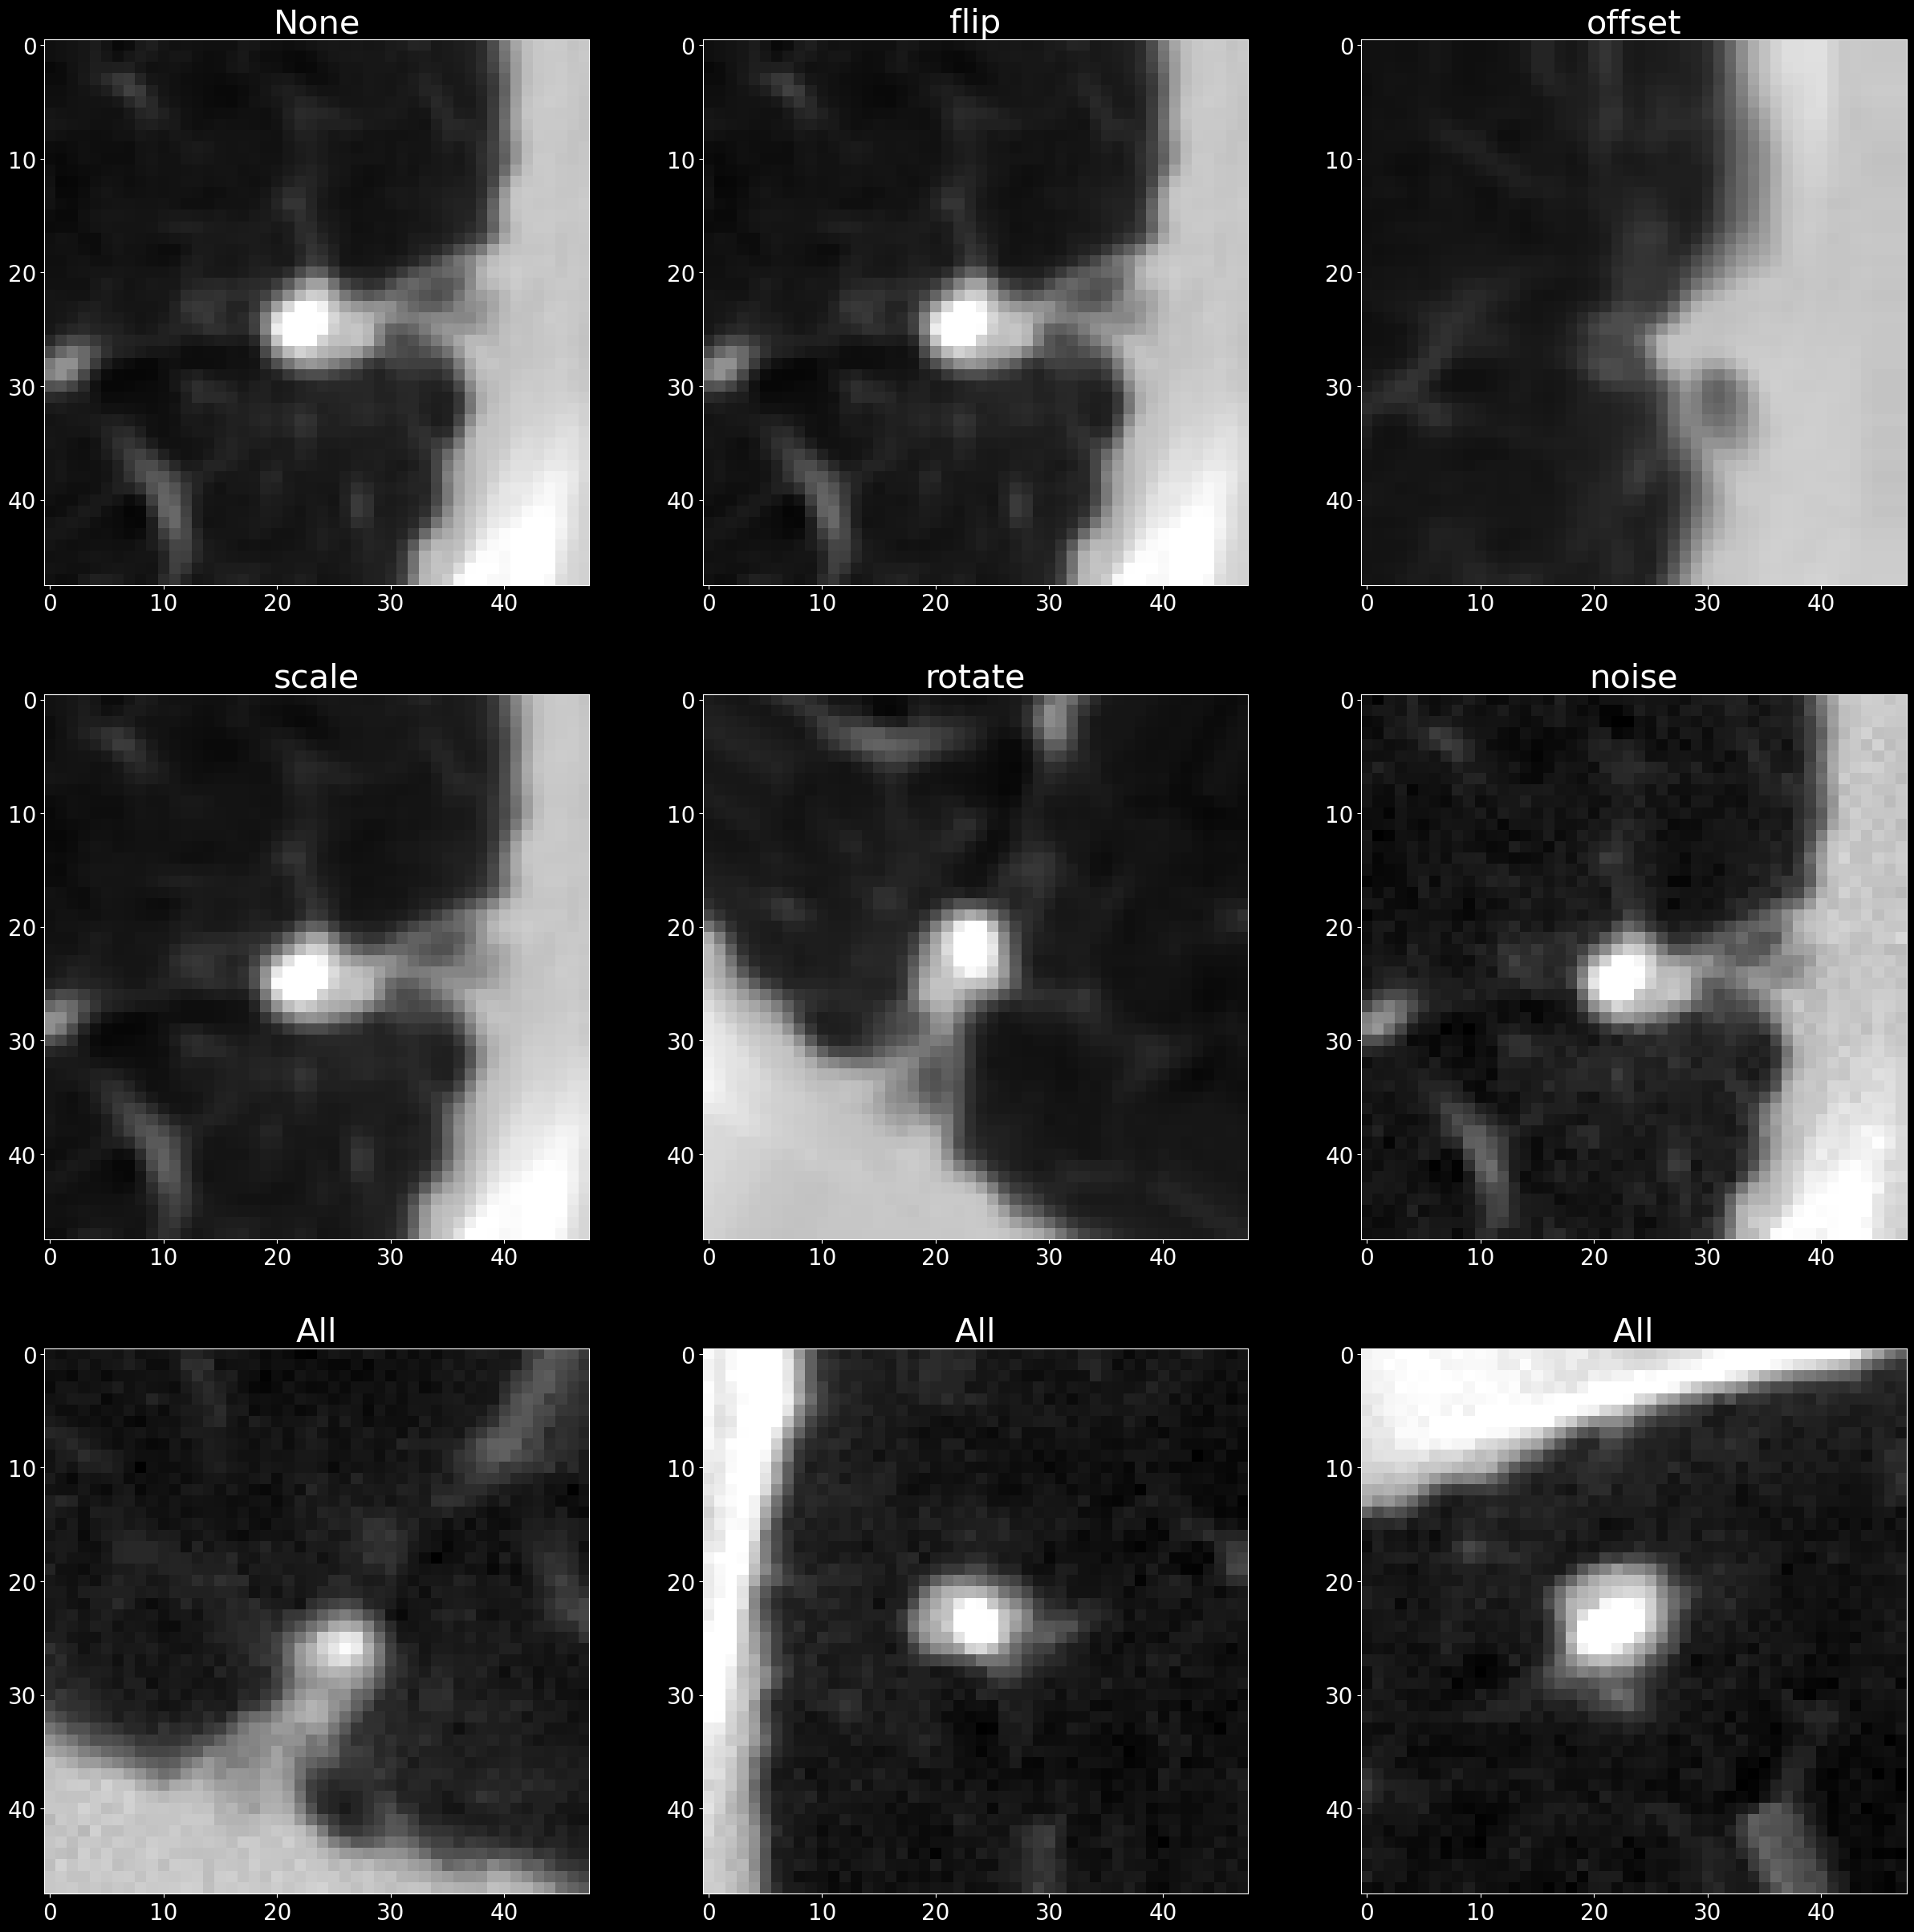

In [11]:
sample_ndx = 100
# sample_ndx = 154
# sample_ndx = 155


sample_tup = all_ds[sample_ndx]
print(sample_tup[0].shape, sample_tup[1:])

fig = plt.figure(figsize=(20, 20))

clim=(-1000.0, 300)

for i, ((title_str, _), ds) in enumerate(zip(augmentation_list, ds_list)):
    sample_tup = ds[sample_ndx]
    subplot = fig.add_subplot(3, 3, i+1)
    subplot.set_title(title_str, fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(sample_tup[0][0][16], clim=clim, cmap='gray')

plt.show()